In [1]:
# Cell 0 — WSL GPU + all imports (do not split TensorFlow into another cell).
# TF loads CUDA on first import; if it imported earlier without LD_LIBRARY_PATH, GPU stays [] until Kernel Restart.
import os
import sys
from pathlib import Path


def _detect_venv() -> str:
    v = os.environ.get("VIRTUAL_ENV")
    if v:
        return v
    exe = Path(sys.executable).resolve()
    if exe.parent.name == "bin" and (exe.parent.parent / "pyvenv.cfg").is_file():
        return str(exe.parent.parent)
    raise RuntimeError(
        "Select kernel: skin-cancer-project/venv/bin/python (venv). "
        "VIRTUAL_ENV unset and interpreter is not inside a venv."
    )


venv = _detect_venv()
_pyv = f"{sys.version_info.major}.{sys.version_info.minor}"
_base = f"{venv}/lib/python{_pyv}/site-packages/nvidia"
_cuda_libs = [
    "/usr/lib/wsl/lib",
    f"{_base}/cuda_runtime/lib",
    f"{_base}/cuda_nvrtc/lib",
    f"{_base}/cublas/lib",
    f"{_base}/cudnn/lib",
    f"{_base}/cufft/lib",
    f"{_base}/curand/lib",
    f"{_base}/cusolver/lib",
    f"{_base}/cusparse/lib",
    f"{_base}/nccl/lib",
    f"{_base}/nvjitlink/lib",
]
_prev = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = ":".join([p for p in _cuda_libs + ([_prev] if _prev else []) if p])

missing = [p for p in _cuda_libs if not Path(p).is_dir()]
if missing:
    print("WARNING: missing NVIDIA wheel dirs:", missing)

print("venv:", venv)
print("Python:", sys.version.split()[0])
print("LD_LIBRARY_PATH prefix:", os.environ["LD_LIBRARY_PATH"][:140] + "...")

# Help the dynamic linker load CUDA deps before TensorFlow's GPU plugin dlopens them
# (needed on some WSL + Jupyter kernels even when LD_LIBRARY_PATH is set).
import ctypes

_preloads = [
    Path(_base) / "cuda_runtime" / "lib" / "libcudart.so.12",
    Path(_base) / "cudnn" / "lib" / "libcudnn.so.9",
    Path(_base) / "cublas" / "lib" / "libcublas.so.12",
    Path(_base) / "cublas" / "lib" / "libcublasLt.so.12",
    Path(_base) / "cusolver" / "lib" / "libcusolver.so.11",
    Path(_base) / "cusparse" / "lib" / "libcusparse.so.12",
]
for _so in _preloads:
    if _so.is_file():
        try:
            ctypes.CDLL(str(_so), mode=ctypes.RTLD_GLOBAL)
            print("Preloaded:", _so.name)
        except OSError as _e:
            print("Preload skipped/failed:", _so, _e)

# Import TensorFlow in THIS cell immediately after LD_LIBRARY_PATH + preload (required on WSL).
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow:", tf.__version__)
print("GPU devices:", gpus)

venv: /home/hansdaduya/projects/skin-cancer-project/venv
Python: 3.12.3
LD_LIBRARY_PATH prefix: /usr/lib/wsl/lib:/home/hansdaduya/projects/skin-cancer-project/venv/lib/python3.12/site-packages/nvidia/cuda_runtime/lib:/home/hansdaduya/pr...
Preloaded: libcudart.so.12
Preloaded: libcudnn.so.9
Preloaded: libcublas.so.12
Preloaded: libcublasLt.so.12
Preloaded: libcusolver.so.11
Preloaded: libcusparse.so.12


I0000 00:00:1777971492.510366    2879 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 2: Paths + load metadata
DATA_DIR = "/home/hansdaduya/projects/skin-cancer-project/datasets/ham10000"
METADATA = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

df = pd.read_csv(METADATA)
print("Rows:", len(df))
print(df.head(3))
print(df["dx"].value_counts())

Rows: 10015
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [3]:
# Cell 3: Map image_id -> file path (handles both uppercase/lowercase folders)
candidate_dirs = [
    "HAM10000_images_part_1", "HAM10000_images_part_2",
    "ham10000_images_part_1", "ham10000_images_part_2",
]

image_paths = {}
for folder in candidate_dirs:
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path):
        continue
    for fn in os.listdir(folder_path):
        if fn.endswith(".jpg"):
            image_paths[fn.replace(".jpg", "")] = os.path.join(folder_path, fn)

df["path"] = df["image_id"].map(image_paths)
print("Missing paths:", df["path"].isna().sum())
assert df["path"].isna().sum() == 0, "Some image paths are missing!"

Missing paths: 0


In [4]:
# Cell 4: Collapse 7 classes -> 3 classes
CLASS_MAP = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "pre_cancerous",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign",
}

LABELS = ["benign", "pre_cancerous", "malignant"]
label_to_idx = {l: i for i, l in enumerate(LABELS)}

df["label_3"] = df["dx"].map(CLASS_MAP)
df["label_idx"] = df["label_3"].map(label_to_idx)

print(df["label_3"].value_counts())

label_3
benign           8061
malignant        1627
pre_cancerous     327
Name: count, dtype: int64


In [5]:
# Cell 5: Stratified split + class weights
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label_idx"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_idx"], random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(LABELS)),
    y=train_df["label_idx"].values
)
class_weights_dict = {i: float(w) for i, w in enumerate(class_weights)}
print("Class weights:", class_weights_dict)

Train: 7010, Val: 1502, Test: 1503
Class weights: {0: 0.4141557367363819, 1: 10.203784570596797, 2: 2.051507170032192}


In [6]:
# Cell 6: tf.data pipeline
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    return img, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["path"].values, dataframe["label_idx"].values)
    )
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

I0000 00:00:1777971497.260559    2879 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:0b:00.0, compute capability: 8.9


In [7]:
# Cell 7: Build model (EfficientNetB0)
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(len(LABELS), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
# Cell 8: Train phase 1 (frozen backbone)
callbacks_phase1 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss"),
    ModelCheckpoint("models/best_model_phase1.keras", save_best_only=True, monitor="val_accuracy"),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=callbacks_phase1,
)

Epoch 1/15


I0000 00:00:1777971515.154733    4743 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 722 of 2000
I0000 00:00:1777971506.449343    4743 shuffle_dataset_op.cc:483] Shuffle buffer filled.
I0000 00:00:1777971506.746605    4612 service.cc:153] XLA service 0x78bb14067d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777971506.746655    4612 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777971507.463659    4612 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777971509.546748    4612 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777971509.850203    4612 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16194__.252
E0000 00:00:1777971512.454627    4612 cuda_time

124/220 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.5687 - loss: 1.0703

I0000 00:00:1777971539.979673    4610 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16194__.252
E0000 00:00:1777971545.109597    4610 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777971545.428613    4610 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777971546.383682    4610 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5940 - loss: 0.9885 

...

  3/220 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.7014 - loss: 0.5734

I0000 00:00:1777971606.393200    8694 shuffle_dataset_op.cc:483] Shuffle buffer filled.


220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.6950 - loss: 0.6308 - val_accuracy: 0.7190 - val_loss: 0.5713 - learning_rate: 0.0010
Epoch 6/15
  1/220 ━━━━━━━━━━━━━━━━━━━━ 39:06 11s/step - accuracy: 0.6562 - loss: 1.0430

I0000 00:00:1777971625.514651    8849 shuffle_dataset_op.cc:483] Shuffle buffer filled.


220/220 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.6991 - loss: 0.6021 - val_accuracy: 0.7024 - val_loss: 0.6101 - learning_rate: 0.0010
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.7134 - loss: 0.5959 - val_accuracy: 0.6957 - val_loss: 0.6127 - learning_rate: 0.0010
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.7201 - loss: 0.5683 - val_accuracy: 0.7377 - val_loss: 0.5635 - learning_rate: 0.0010
Epoch 9/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.7144 - loss: 0.5794 - val_accuracy: 0.7004 - val_loss: 0.5929 - learning_rate: 0.0010
Epoch 10/15
220/220 ━━━━━━━━━━━━━━━━━━━━ -1s 35ms/step - accuracy: 0.7223 - loss: 0.5631 - val_accuracy: 0.6658 - val_loss: 0.7146 - learning_rate: 0.0010
Epoch 11/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.7247 - loss: 0.5449 - val_accuracy: 0.6944 - val_loss: 0.6336 - learning_rate: 0.0010
Epoch 12/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7345 - loss: 0.5176 

In [9]:
# Cell 9: Fine-tune phase 2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_phase2 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss"),
    ModelCheckpoint("models/best_model_phase2.keras", save_best_only=True, monitor="val_accuracy"),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=callbacks_phase2,
)

Epoch 1/20


I0000 00:00:1777971725.495744   10275 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1132 of 2000
I0000 00:00:1777971725.835821   10275 shuffle_dataset_op.cc:483] Shuffle buffer filled.
I0000 00:00:1777971728.801478    4609 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59293__.280
E0000 00:00:1777971732.252621    4609 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


120/220 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.6213 - loss: 1.0548

I0000 00:00:1777971742.577095    4610 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59293__.280


220/220 ━━━━━━━━━━━━━━━━━━━━ 65s 146ms/step - accuracy: 0.6301 - loss: 0.9880 - val_accuracy: 0.6924 - val_loss: 0.7107 - learning_rate: 1.0000e-05
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.6478 - loss: 0.8116 - val_accuracy: 0.6877 - val_loss: 0.7396 - learning_rate: 1.0000e-05
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.6645 - loss: 0.7429 - val_accuracy: 0.6931 - val_loss: 0.7144 - learning_rate: 1.0000e-05
Epoch 4/20
  1/220 ━━━━━━━━━━━━━━━━━━━━ 43:41 12s/step - accuracy: 0.6875 - loss: 1.4299

I0000 00:00:1777971805.619733   11796 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1977 of 2000
I0000 00:00:1777971805.634213   11796 shuffle_dataset_op.cc:483] Shuffle buffer filled.


220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.6645 - loss: 0.7011 - val_accuracy: 0.6944 - val_loss: 0.7049 - learning_rate: 1.0000e-05
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.6786 - loss: 0.6853 - val_accuracy: 0.6964 - val_loss: 0.6823 - learning_rate: 1.0000e-05
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.6909 - loss: 0.6422 - val_accuracy: 0.7064 - val_loss: 0.6658 - learning_rate: 1.0000e-05
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.6964 - loss: 0.6247 - val_accuracy: 0.7077 - val_loss: 0.6566 - learning_rate: 1.0000e-05
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s -2939us/step - accuracy: 0.7074 - loss: 0.6011 - val_accuracy: 0.7091 - val_loss: 0.6520 - learning_rate: 1.0000e-05
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.7104 - loss: 0.5937 - val_accuracy: 0.7097 - val_loss: 0.6449 - learning_rate: 1.0000e-05
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accu

E0000 00:00:1777972044.876111    4610 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777972045.806163    4610 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777972048.010316    4610 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


               precision    recall  f1-score   support

       benign       0.97      0.75      0.85      1210
pre_cancerous       0.27      0.80      0.40        49
    malignant       0.41      0.69      0.51       244

     accuracy                           0.75      1503
    macro avg       0.55      0.75      0.59      1503
 weighted avg       0.85      0.75      0.78      1503



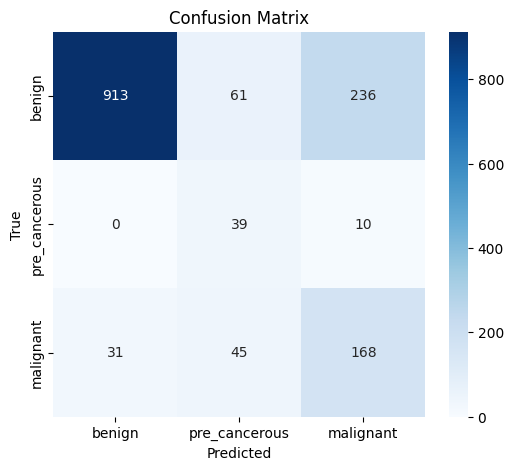

In [10]:
# Cell 10: Evaluate
y_true, y_pred = [], []

for x_batch, y_batch in test_ds:
    probs = model.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(probs, axis=1))

print(classification_report(y_true, y_pred, target_names=LABELS))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [11]:
# Cell 11: Export .keras + .tflite + labels
os.makedirs("models", exist_ok=True)
test_df.to_csv("models/test_split.csv", index=False)

model.save("models/skin_classifier_full.keras")

calib_ds = make_dataset(train_df, training=False)

def representative_dataset():
    for x_batch, _ in calib_ds.take(100):
        yield [x_batch]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
tflite_model = converter.convert()

with open("models/skin_classifier.tflite", "wb") as f:
    f.write(tflite_model)

with open("models/labels.txt", "w") as f:
    f.write("\n".join(LABELS))

print("Saved:")
print("- models/skin_classifier_full.keras")
print("- models/skin_classifier.tflite")
print("- models/labels.txt")

INFO:tensorflow:Assets written to: /tmp/tmpoinhm2io/assets


INFO:tensorflow:Assets written to: /tmp/tmpoinhm2io/assets


Saved artifact at '/tmp/tmpoinhm2io'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132747709489680: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132747709490256: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132748448227088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748448229200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748448228816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748448229968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748448225936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748448229776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748448231888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748448232080: TensorSpec(shape=(), dtype=tf.resource, name=None

/home/hansdaduya/projects/skin-cancer-project/venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1777972064.397659    2879 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1777972064.397704    2879 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1777972064.401673    2879 reader.cc:83] Reading SavedModel from: /tmp/tmpoinhm2io
I0000 00:00:1777972064.418059    2879 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1777972064.418088    2879 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpoinhm2io
I0000 00:00:1777972064.528406    2879 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1777972064.550283    2879 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1777972065.094385    2879 loader.cc:220] Running ini

Saved:
- models/skin_classifier_full.keras
- models/skin_classifier.tflite
- models/labels.txt
